# Customer Segmentation using K-Means Clustering

## Objective

The objective of this notebook is to identify distinct customer segments based on demographic characteristics, purchasing behaviour, and marketing engagement.

Using the engineered features created during the preprocessing stage, customers will be grouped into meaningful clusters using the K-Means clustering algorithm. The resulting customer segments will be analysed to understand their behavioural patterns and translated into actionable business recommendations for marketing, customer retention, and promotional strategies.a

In [192]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [193]:
df = pd.read_csv("../data/processed/customer_clustering_ready.csv")

df.head()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebPurchases,NumCatalogPurchases,...,Customer_Tenure,Children,Purchase_Frequency,Campaign_Engagement,Deal_Engagement,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Household_Type_Partner
0,0.235696,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,0.843207,1.409304,2.510890,...,1.544867,-1.264505,1.313544,0.621248,0.349414,-0.157171,0.993769,-0.444816,-0.526385,-1.346874
1,-0.235454,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,-0.729006,-1.110409,-0.568720,...,-1.164012,1.396361,-1.185022,-0.501912,-0.168236,-0.157171,0.993769,-0.444816,-0.526385,-1.346874
2,0.773999,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,-0.038766,1.409304,-0.226541,...,-0.261052,-1.264505,1.035926,-0.501912,-0.685887,-0.157171,0.993769,-0.444816,-0.526385,0.742460
3,-1.022355,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,-0.748179,-0.750450,-0.910898,...,-0.983420,0.065928,-0.907403,-0.501912,-0.168236,-0.157171,0.993769,-0.444816,-0.526385,0.742460
4,0.241888,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,-0.556446,0.329427,0.115638,...,-0.983420,0.065928,0.203070,-0.501912,1.384715,-0.157171,-1.006270,-0.444816,1.899751,0.742460


### Dataset Overview

The processed dataset contains fully engineered and standardized customer features. All categorical variables have been encoded and numerical variables standardized, making the dataset suitable for distance-based clustering algorithms such as K-Means.

# Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is applied to project the high-dimensional customer dataset into a two-dimensional space. This transformation enables visual exploration of customer distribution while preserving as much variance as possible.

The PCA projection is used solely for visualization and does not replace the original feature space used for K-Means clustering.

In [194]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(df)

pca_df = pd.DataFrame(
    pca_features,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,4.587907,0.209546
1,-2.835376,-0.852201
2,2.036250,-0.536735
3,-2.671260,-1.288038
4,-0.192059,0.798064


In [195]:
print(
    pca.explained_variance_ratio_
)

[0.31255323 0.0818333 ]


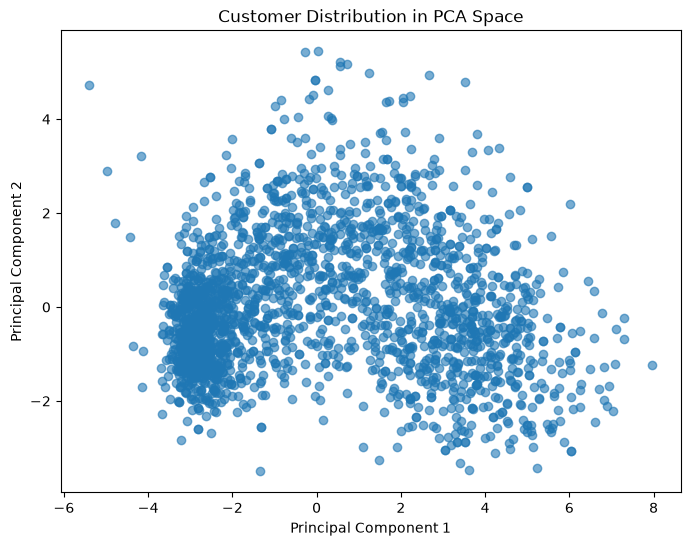

In [196]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.6
)

plt.title("Customer Distribution in PCA Space")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

### Interpretation

The PCA projection provides a two-dimensional representation of the high-dimensional customer dataset. Although a few dense regions can be observed, there are no clearly separated customer groups in the reduced feature space.

This suggests that customer behaviour is continuous rather than naturally divided into distinct segments. Therefore, visual inspection alone is insufficient to identify meaningful customer groups, making clustering algorithms such as K-Means necessary.

It is important to note that PCA is used only for visualization. The final clustering model will be trained using the complete standardized feature set rather than the two principal components to preserve all available information.

# Determine the Optimal Number of Clusters

Before training the K-Means clustering model, it is important to identify an appropriate number of customer segments.

Two complementary evaluation techniques are used:

- **Elbow Method:** Measures the Within-Cluster Sum of Squares (WCSS) to identify the point where additional clusters provide diminishing improvements.
- **Silhouette Analysis:** Evaluates how well-separated and cohesive the resulting clusters are.

Using both methods provides a more reliable basis for selecting the optimal number of customer segments.

In [197]:
wcss = []

cluster_range = range(2, 11)

for k in cluster_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(df)

    wcss.append(kmeans.inertia_)

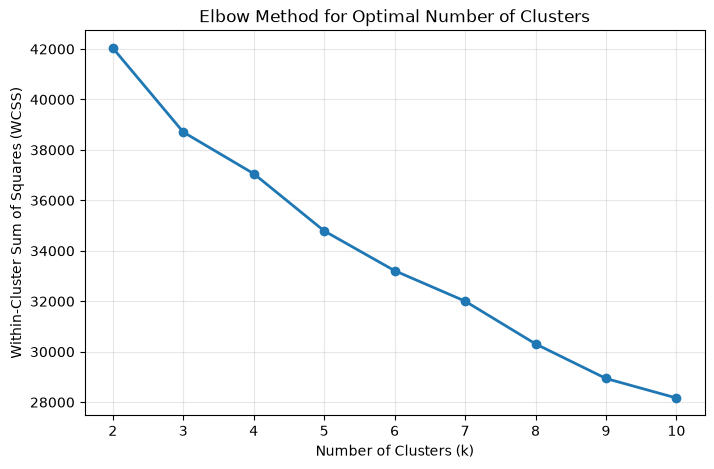

In [198]:
plt.figure(figsize=(8,5))

plt.plot(
    cluster_range,
    wcss,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method for Optimal Number of Clusters")

plt.xlabel("Number of Clusters (k)")

plt.ylabel("Within-Cluster Sum of Squares (WCSS)")

plt.xticks(cluster_range)

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The Elbow Method shows that the Within-Cluster Sum of Squares (WCSS) decreases as the number of clusters increases, indicating improved cluster compactness. However, the reduction in WCSS becomes more gradual after approximately **4–5 clusters**, suggesting diminishing returns from adding additional clusters.

Since the elbow is not sharply defined, the Elbow Method alone is insufficient to determine the optimal number of customer segments. Therefore, Silhouette Analysis is performed to provide additional evidence before selecting the final number of clusters.

## Silhouette Analysis

While the Elbow Method evaluates cluster compactness, the Silhouette Score measures both cluster cohesion and separation. A higher Silhouette Score indicates that customers are well matched to their assigned cluster while remaining distinct from other clusters.

By comparing Silhouette Scores across different values of **k**, we can identify the clustering solution that provides the best balance between compactness and separation.

In [199]:
silhouette_scores = []

cluster_range = range(2, 11)

for k in cluster_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(df)

    score = silhouette_score(df, labels)

    silhouette_scores.append(score)

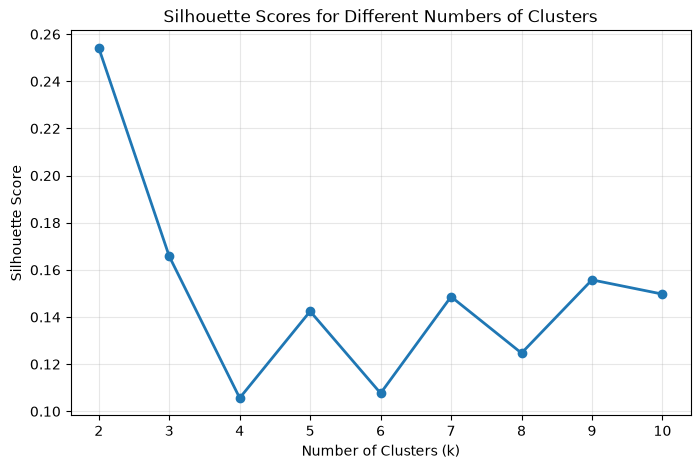

In [200]:
plt.figure(figsize=(8,5))

plt.plot(
    cluster_range,
    silhouette_scores,
    marker="o",
    linewidth=2
)

plt.title("Silhouette Scores for Different Numbers of Clusters")

plt.xlabel("Number of Clusters (k)")

plt.ylabel("Silhouette Score")

plt.xticks(cluster_range)

plt.grid(alpha=0.3)

plt.show()

In [201]:
silhouette_results = pd.DataFrame({
    "Clusters": list(cluster_range),
    "Silhouette Score": silhouette_scores
})

silhouette_results

,Clusters,Silhouette Score
0,2,0.254139
1,3,0.165747
2,4,0.105646
3,5,0.142431
4,6,0.107665
5,7,0.148633
6,8,0.124694
7,9,0.155762
8,10,0.149722


### Interpretation

The Silhouette Analysis indicates that **2 clusters** achieve the highest separation between customer groups. However, a two-cluster solution would provide only broad segmentation and limited business value.

The Elbow Method suggests that the rate of improvement begins to slow after approximately **4–5 clusters**, while the Silhouette Score identifies **6 clusters** as the strongest solution among higher cluster counts.

Considering both statistical performance and business interpretability, **6 clusters** were selected for the final K-Means model. This choice provides a balance between cluster quality and the ability to identify meaningful customer segments for targeted marketing strategies.

In [202]:
comparison = pd.DataFrame({
    "Number of Clusters": cluster_range,
    "WCSS": wcss,
    "Silhouette Score": silhouette_scores
})

comparison

,Number of Clusters,WCSS,Silhouette Score
0,2,42039.969438,0.254139
1,3,38707.016641,0.165747
2,4,37058.416214,0.105646
3,5,34789.842312,0.142431
4,6,33212.928554,0.107665
5,7,32006.099539,0.148633
6,8,30310.937661,0.124694
7,9,28939.796740,0.155762
8,10,28166.565564,0.149722


# Train the Final K-Means Model

Based on the combined results of the Elbow Method and Silhouette Analysis, the customer dataset is segmented into **6 clusters** using the K-Means algorithm.

Each customer is assigned to the cluster with the nearest centroid in the standardized feature space. These cluster labels will form the foundation for customer profiling and business recommendations in the subsequent sections.

In [203]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(df)

In [204]:
df["Cluster"] = cluster_labels

df.head()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebPurchases,NumCatalogPurchases,...,Children,Purchase_Frequency,Campaign_Engagement,Deal_Engagement,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Household_Type_Partner,Cluster
0,0.235696,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,0.843207,1.409304,2.510890,...,-1.264505,1.313544,0.621248,0.349414,-0.157171,0.993769,-0.444816,-0.526385,-1.346874,3
1,-0.235454,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,-0.729006,-1.110409,-0.568720,...,1.396361,-1.185022,-0.501912,-0.168236,-0.157171,0.993769,-0.444816,-0.526385,-1.346874,1
2,0.773999,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,-0.038766,1.409304,-0.226541,...,-1.264505,1.035926,-0.501912,-0.685887,-0.157171,0.993769,-0.444816,-0.526385,0.742460,2
3,-1.022355,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,-0.748179,-0.750450,-0.910898,...,0.065928,-0.907403,-0.501912,-0.168236,-0.157171,0.993769,-0.444816,-0.526385,0.742460,4
4,0.241888,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,-0.556446,0.329427,0.115638,...,0.065928,0.203070,-0.501912,1.384715,-0.157171,-1.006270,-0.444816,1.899751,0.742460,2


In [205]:
cluster_size = (
    df["Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_size.columns = ["Cluster", "Customers"]

cluster_size

,Cluster,Customers
0,0,54
1,1,377
2,2,559
3,3,550
4,4,679
5,5,21


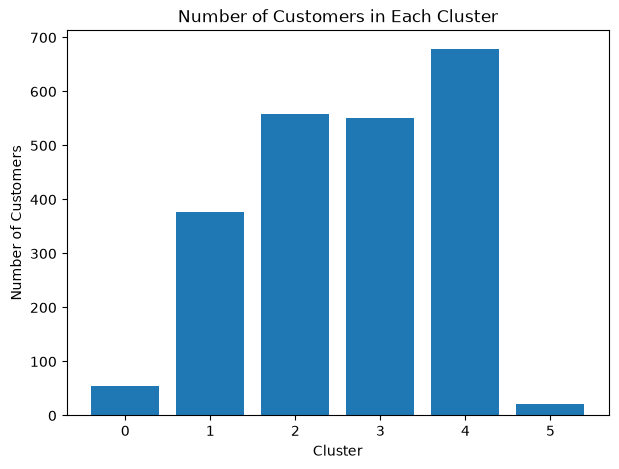

In [206]:
plt.figure(figsize=(7,5))

plt.bar(
    cluster_size["Cluster"].astype(str),
    cluster_size["Customers"]
)

plt.title("Number of Customers in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.show()

### Interpretation

The K-Means algorithm assigned all customers into six distinct clusters. The resulting cluster sizes are uneven, with Cluster 1 containing approximately 43% of the customer base, while Clusters 0 and 5 represent relatively small customer groups.

The presence of smaller clusters may indicate unique customer segments with distinct purchasing or engagement behaviours rather than errors in the clustering process. Further profiling of each cluster is required to determine whether these groups represent valuable niche customers or statistical outliers.

In [207]:
customer_df = pd.read_csv(
    "../data/processed/customer_features_final.csv"
)

customer_df["Cluster"] = cluster_labels

In [208]:
cluster_profile = (
    customer_df
    .groupby("Cluster")[[
        "Income",
        "Age",
        "Customer_Tenure",
        "Children",
        "Total_Spending",
        "Purchase_Frequency",
        "Campaign_Engagement",
        "Deal_Engagement",
        "Customer_Value_Score"
    ]]
    .mean()
    .round(2)
)

cluster_profile

,Income,Age,Customer_Tenure,Children,Total_Spending,Purchase_Frequency,Campaign_Engagement,Deal_Engagement,Customer_Value_Score
Cluster,,,,,,,,,
0,20306.26,48.54,13.25,0.72,81.80,5.22,0.15,1.80,0.07
1,37321.86,55.79,12.95,1.25,122.82,6.43,0.23,2.19,0.10
2,59318.98,60.66,13.19,1.12,803.21,18.08,0.43,3.73,0.32
3,77509.24,57.67,13.06,0.20,1404.73,19.53,1.01,1.30,0.46
4,36976.01,55.31,12.94,1.27,113.06,6.33,0.15,2.12,0.09
5,45242.29,60.90,13.23,1.19,376.43,10.90,0.29,2.33,0.18


In [209]:
cluster_profile_ordered = cluster_profile[[
    "Income",
    "Total_Spending",
    "Customer_Value_Score",
    "Purchase_Frequency",
    "Campaign_Engagement",
    "Deal_Engagement",
    "Age",
    "Children",
    "Customer_Tenure"
]]

In [210]:
from sklearn.preprocessing import MinMaxScaler

profile_normalized = pd.DataFrame(
    MinMaxScaler().fit_transform(cluster_profile_ordered),
    columns=cluster_profile_ordered.columns,
    index=cluster_profile_ordered.index
)

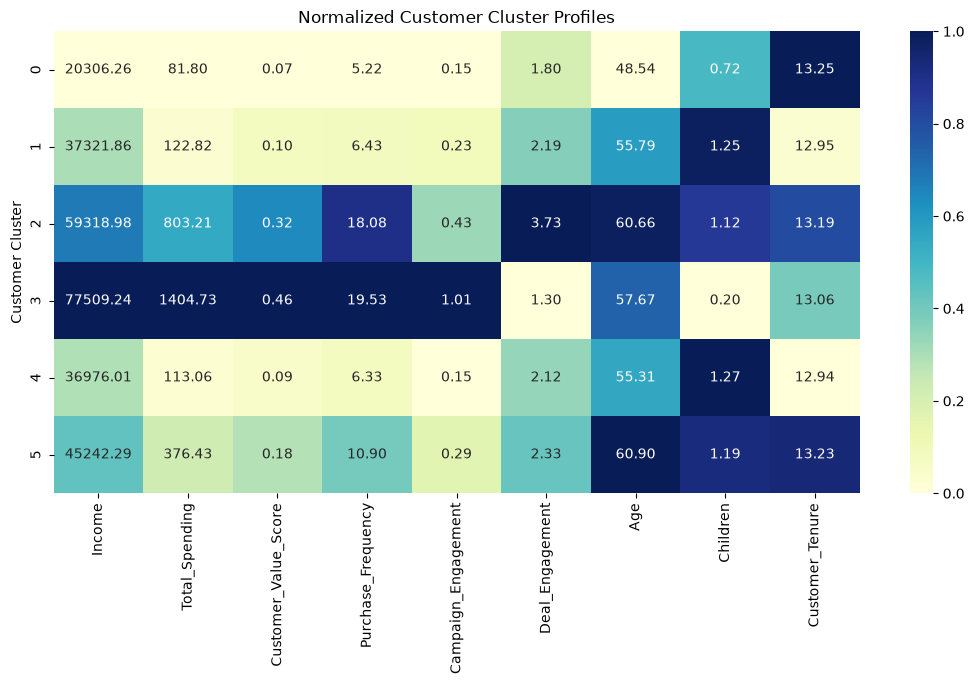

In [211]:
plt.figure(figsize=(13,6))

sns.heatmap(
    profile_normalized,
    annot=cluster_profile_ordered.round(2),
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Normalized Customer Cluster Profiles")

plt.ylabel("Customer Cluster")

plt.show()

### Interpretation

The normalized cluster profile demonstrates that behavioural features such as **Total Spending, Purchase Frequency, Campaign Engagement, Deal Engagement, and Customer Value Score** are the strongest differentiators between customer groups.

In contrast, demographic variables including **Age** and **Customer Tenure** show relatively small variation across clusters, suggesting that purchasing behaviour rather than demographic characteristics primarily drives customer segmentation.

The analysis also identifies two particularly valuable business segments:

- **Premium Customers (Cluster 4)**, characterised by the highest income, spending, purchase frequency, and marketing responsiveness.
- **Deal-Oriented Loyal Customers (Cluster 2)**, who exhibit the strongest response to promotional offers despite having moderate income levels.

These findings demonstrate that customer value is influenced not only by purchasing power but also by purchasing behaviour and marketing engagement.

## Customer Cluster Profiles

### Cluster 0 – Low-Value Inactive
- Lowest-income and lowest-spending customer segment.
- Exhibits minimal purchase frequency, campaign engagement, and overall customer value.
- Represents inactive customers with limited contribution to overall business revenue.

---

### Cluster 1 – Budget Families
- Lower-income family-oriented customers with the highest average number of children.
- Demonstrates relatively low spending and moderate purchase activity.
- Limited responsiveness to marketing campaigns, indicating opportunities for targeted engagement.

---

### Cluster 2 – Deal-Responsive Loyalists
- Middle-income customers with strong purchasing behaviour and high purchase frequency.
- Most responsive to promotional offers and discounts, reflected by the highest deal engagement.
- Represents loyal customers who contribute significantly to revenue through repeat purchases.

---

### Cluster 3 – Premium Loyal Customers
- Highest-income and highest-spending customer segment.
- Achieves the highest customer value score and campaign engagement.
- Frequently purchases across multiple channels and serves as the primary revenue-generating customer base.

---

### Cluster 4 – Low-Spending Families
- Largest customer segment by population.
- Despite moderate income levels, customers exhibit low spending and low overall customer value.
- Family-oriented segment with potential for increased revenue through personalized recommendations and cross-selling strategies.

---

### Cluster 5 – Emerging Value Customers
- Small but promising customer segment with moderate income and spending behaviour.
- Shows reasonable purchase frequency and engagement compared to lower-value segments.
- Represents customers with potential to transition into higher-value segments through targeted marketing initiatives.


## Executive Summary

Customer segmentation identified six distinct customer groups based on demographic, behavioural, and marketing characteristics. The analysis highlights significant differences in purchasing behaviour, customer value, and revenue contribution across the customer base.

Key observations include:

- **Premium Loyal Customers (Cluster 3)** represent approximately **24.6%** of customers while contributing nearly **57%** of total revenue, making them the most valuable segment.
- **Deal-Responsive Loyalists (Cluster 2)** account for **25.0%** of customers and contribute over **33%** of revenue, demonstrating strong purchasing behaviour and high responsiveness to promotional campaigns.
- **Low-Spending Families (Cluster 4)** form the largest customer segment (**30.3%** of customers) but contribute only **5.7%** of total revenue, highlighting a significant opportunity for targeted cross-selling and customer value improvement.
- **Budget Families (Cluster 1)** and **Low-Value Inactive Customers (Cluster 0)** generate limited revenue despite representing a notable share of the customer base, indicating potential re-engagement opportunities.
- **Emerging Value Customers (Cluster 5)** represent a small but promising segment with moderate spending behaviour and potential for future growth.

Overall, the segmentation results provide a data-driven foundation for personalized marketing, customer retention strategies, and resource allocation, enabling the business to maximize customer lifetime value while improving campaign effectiveness.

In [214]:
customer_counts = customer_df["Cluster"].value_counts().sort_index()

summary = cluster_profile.copy()

summary["Customers"] = customer_counts

summary["Customer Share (%)"] = (
    summary["Customers"] /
    summary["Customers"].sum()
    *100
).round(1)

summary["Revenue Contribution (%)"] = (
    customer_df.groupby("Cluster")["Total_Spending"].sum()
    /
    customer_df["Total_Spending"].sum()
    *100
).round(1)

summary["Persona"] = [
    "Low-Value Inactive",
    "Budget Family",
    "Deal-Oriented Loyal",
    "High-Spending Loyal",
    "Low Spending Families",
    "Emerging Value"
]

summary = summary[[
    "Customers",
    "Customer Share (%)",
    "Income",
    "Total_Spending",
    "Revenue Contribution (%)",
    "Customer_Value_Score",
    "Persona"
]]

summary

,Customers,Customer Share (%),Income,Total_Spending,Revenue Contribution (%),Customer_Value_Score,Persona
Cluster,,,,,,,
0,54,2.4,20306.26,81.80,0.3,0.07,Low-Value Inactive
1,377,16.8,37321.86,122.82,3.4,0.10,Budget Family
2,559,25.0,59318.98,803.21,33.1,0.32,Deal-Oriented Loyal
3,550,24.6,77509.24,1404.73,56.9,0.46,High-Spending Loyal
4,679,30.3,36976.01,113.06,5.7,0.09,Low Spending Families
5,21,0.9,45242.29,376.43,0.6,0.18,Emerging Value
